## DSAI3204 – IoT Application Development
## Part B: Time Series Forecasting – Jena Climate Dataset
### Zahra Alwaili 60307052 - Nur Afiqah 60306981

This project develops a leakage-safe 24-hour time series forecasting pipeline for the Jena climate dataset. Integrating coursework concepts with frameworks like Scikit-Learn, LightGBM, Optuna, and Statsmodels, the pipeline evaluates four approaches: a **Persistence Baseline**, **Ridge Regression**, **Random Forest**, and **LightGBM**. Key steps include feature engineering with lagged and rolling metrics ($\ge 24\text{h}$) to eliminate data leakage, time-aware cross-validation, and Optuna hyperparameter tuning. Model behavior and reliability were verified using residual diagnostics (Shapiro–Wilk and Ljung–Box tests), with LLM assistance restricted to debugging and structural optimization.

In [1]:
# installing all libraries

!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn optuna statsmodels scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor                      
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

from scipy import stats                                 

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [2]:
# SECTION 1 – LOAD THE DATASET

df = pd.read_csv('jena_climate_2009_2016.csv')
print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

# Parse date format as it appears in the file
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time').sort_index()

print("\nIndex range:", df.index.min(), "→", df.index.max())

# Resample 10-minute readings to hourly averages
df = df.resample('1h').mean()
print("Hourly shape:", df.shape)

Raw shape: (420551, 15)
Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03           1.75     152.3  
1       1309.80      0.72           1.5


Missing values:
 p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           88
max. wv (m/s)      88
wd (deg)           88
dtype: int64

Descriptive statistics:
        p (mbar)  T (degC)  Tpot (K)  Tdew (degC)    rh (%)  VPmax (mbar)  \
count  70041.00  70041.00  70041.00     70041.00  70041.00      70041.00   
mean     989.21      9.44    283.48         4.95     76.03         13.57   
std        8.36      8.41      8.50         6.73     16.39          7.73   
min      934.91    -22.65    250.97       -24.60     13.68          0.98   
25%      984.21      3.36    277.43         0.23     65.31          7.78   
50%      989.57      9.41    283.46         5.22     79.27         11.82   
75%      994.73     15.46    289.52        10.07     89.35         17.60   
max     1015.24     37.04  

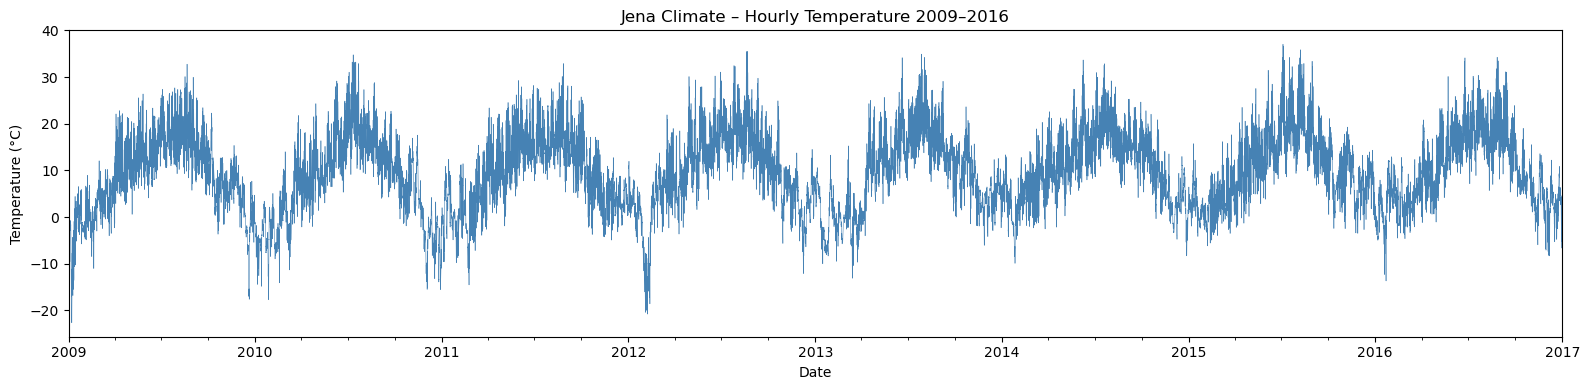

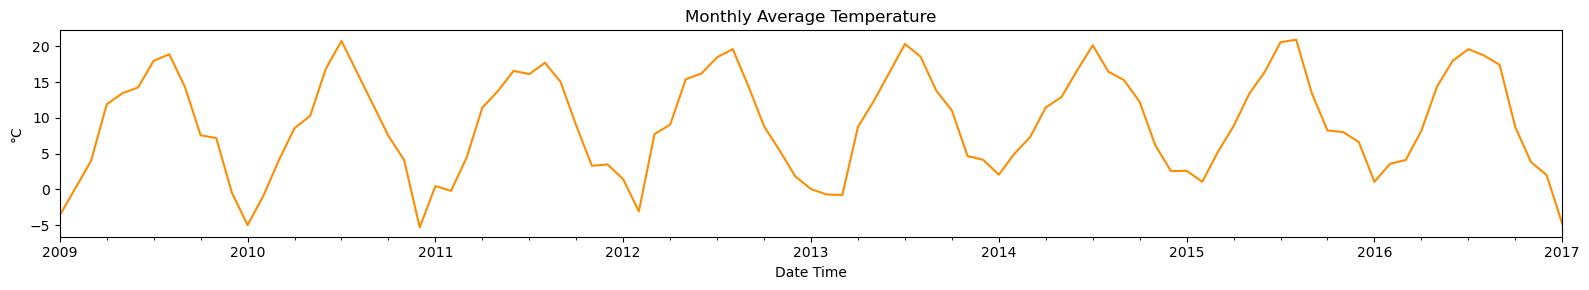

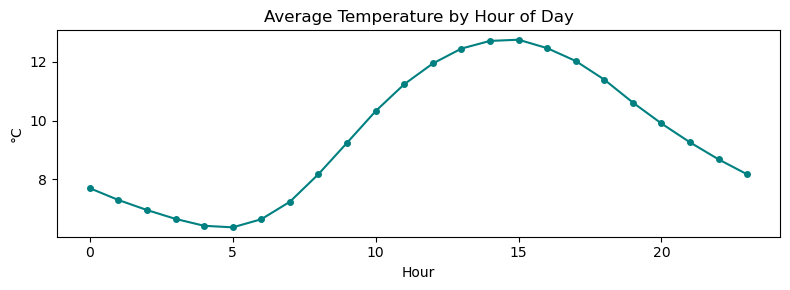

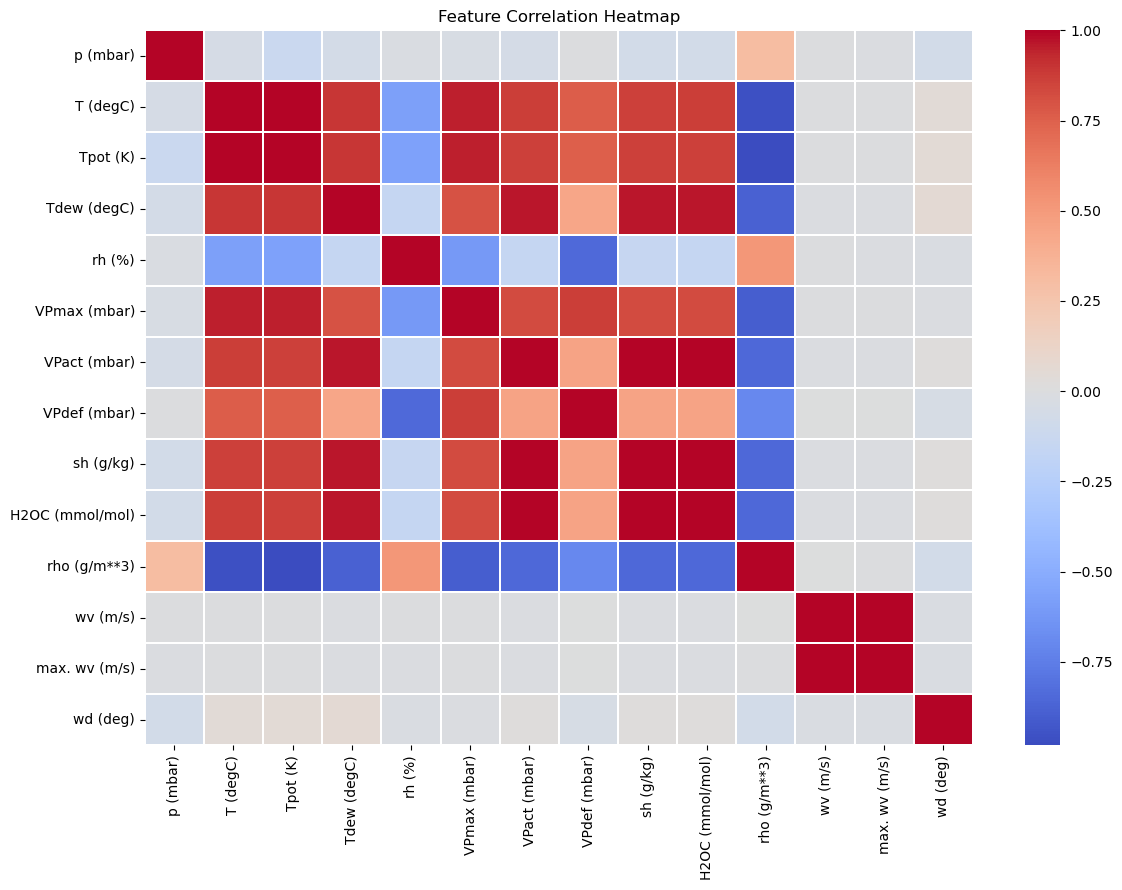

In [3]:
# SECTION 2 – EXPLORATORY DATA ANALYSIS

print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n", df.describe().round(2))

fig, ax = plt.subplots(figsize=(16, 4))
df['T (degC)'].plot(ax=ax, lw=0.4, color='steelblue')
ax.set_title('Jena Climate – Hourly Temperature 2009–2016')
ax.set_ylabel('Temperature (°C)'); ax.set_xlabel('Date')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 3))
df['T (degC)'].resample('ME').mean().plot(ax=ax, color='darkorange', lw=1.5)
ax.set_title('Monthly Average Temperature')
ax.set_ylabel('°C')
plt.tight_layout(); plt.show()

hourly_avg = df.groupby(df.index.hour)['T (degC)'].mean()
fig, ax = plt.subplots(figsize=(8, 3))
hourly_avg.plot(ax=ax, marker='o', ms=4, color='teal')
ax.set_title('Average Temperature by Hour of Day')
ax.set_xlabel('Hour'); ax.set_ylabel('°C')
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()

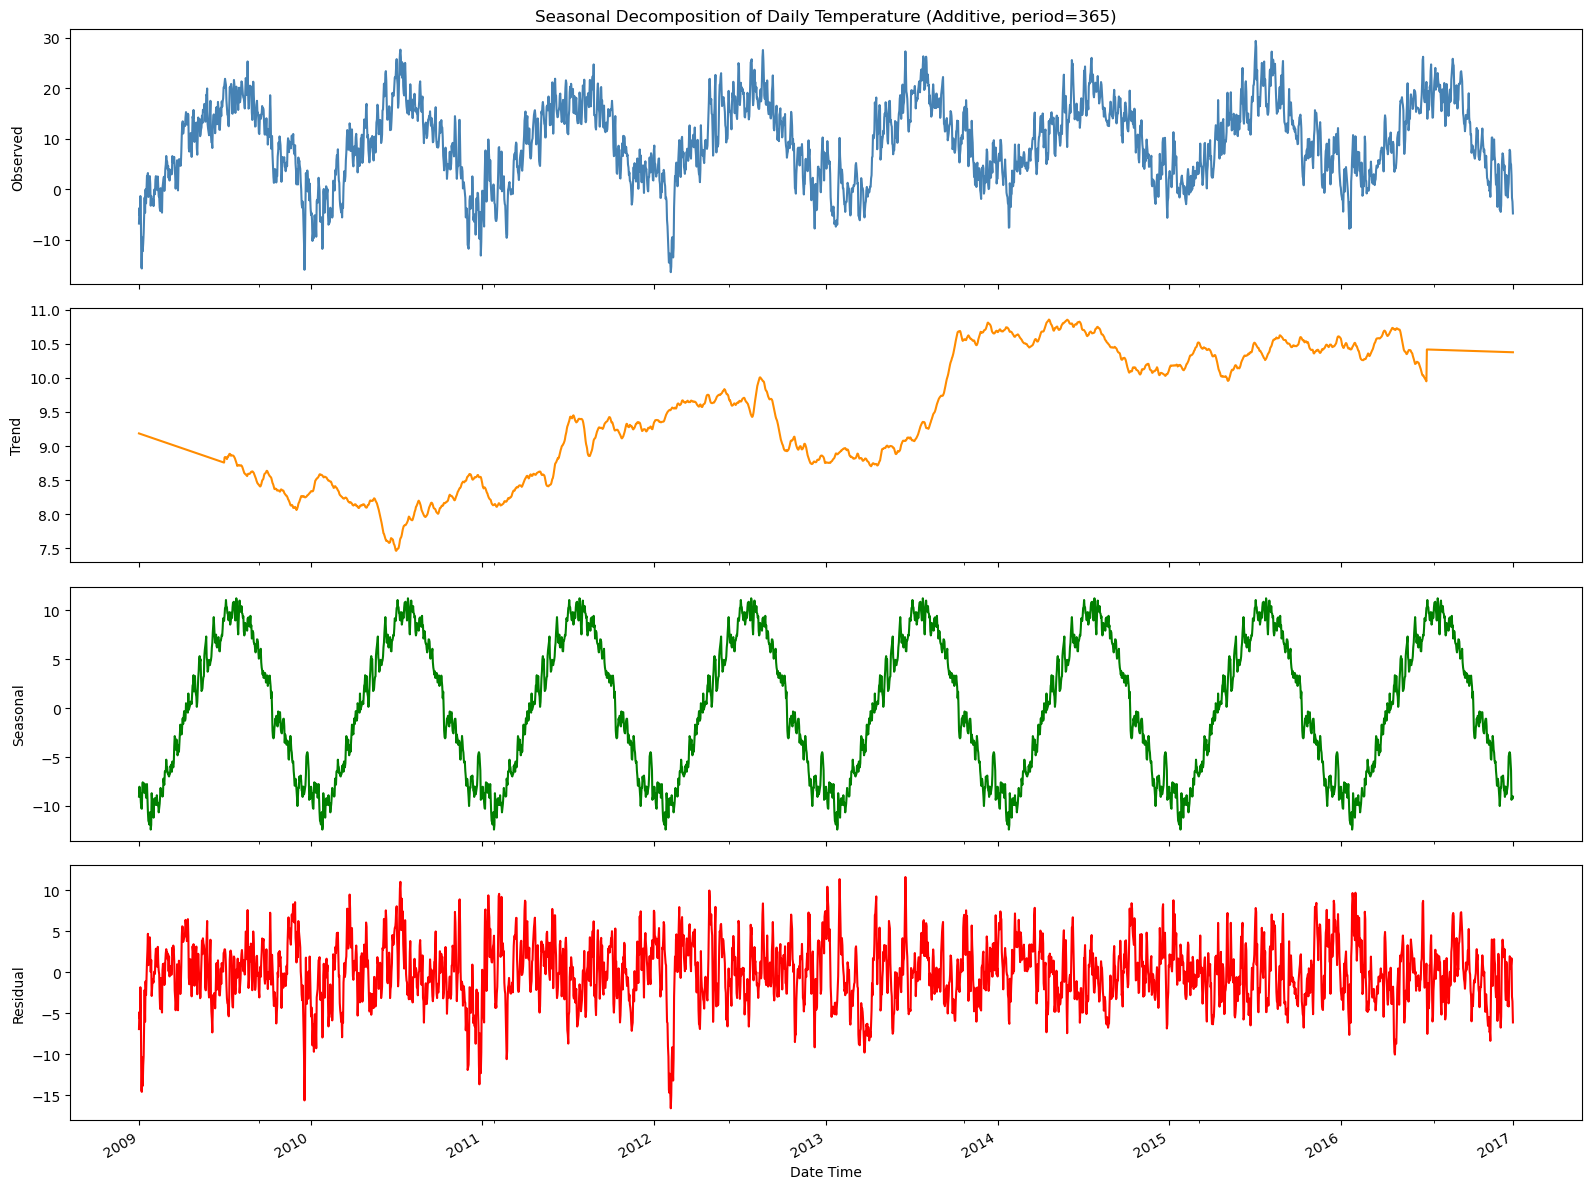

Decomposition results:
  Trend range    : 7.5 → 10.9 °C
  Seasonal range : -12.4 → 11.2 °C
  Residual std   : 3.76 °C

ACF/PACF subsample: 8,760 hourly rows from 2013


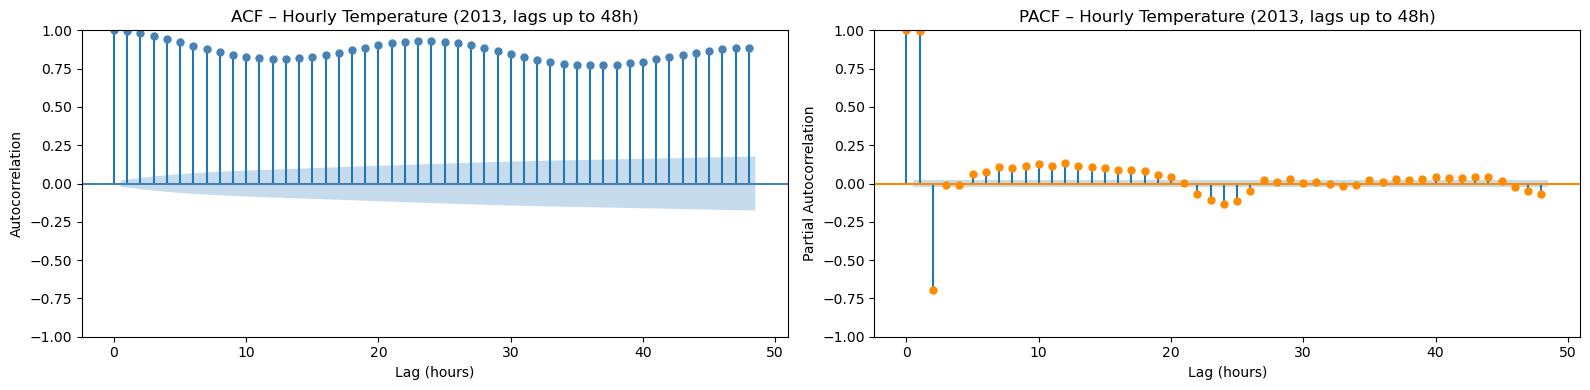


ACF/PACF interpretation:
  Strong spikes at lags 24h and 48h confirm the daily seasonality.
  This directly justifies using T_lag_24h and T_lag_48h as features.
  The slow ACF decay indicates the series is non-stationary (trending).


In [4]:
# SECTION 3 – STATISTICAL TIME SERIES ANALYSIS
# ACF, PACF, and seasonal decomposition reveal the temporal
# structure that justifies our feature engineering choices.

daily = df['T (degC)'].resample('D').mean().dropna()

# Seasonal decomposition on daily data with annual period (365 days)
decomp = seasonal_decompose(daily, model='additive', period=365,
                            extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
decomp.observed.plot(ax=axes[0], color='steelblue');  axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1],    color='darkorange'); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='green');      axes[2].set_ylabel('Seasonal')
decomp.resid.plot(ax=axes[3],    color='red');        axes[3].set_ylabel('Residual')
axes[0].set_title('Seasonal Decomposition of Daily Temperature (Additive, period=365)')
plt.tight_layout(); plt.show()

print("Decomposition results:")
print(f"  Trend range    : {decomp.trend.min():.1f} → {decomp.trend.max():.1f} °C")
print(f"  Seasonal range : {decomp.seasonal.min():.1f} → {decomp.seasonal.max():.1f} °C")
print(f"  Residual std   : {decomp.resid.std():.2f} °C")

one_year = df.loc['2013', 'T (degC)'].dropna()
print(f"\nACF/PACF subsample: {len(one_year):,} hourly rows from 2013")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(one_year, lags=48, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title('ACF – Hourly Temperature (2013, lags up to 48h)')
axes[0].set_xlabel('Lag (hours)'); axes[0].set_ylabel('Autocorrelation')

plot_pacf(one_year, lags=48, ax=axes[1], method='ywm',
          color='darkorange', alpha=0.05)
axes[1].set_title('PACF – Hourly Temperature (2013, lags up to 48h)')
axes[1].set_xlabel('Lag (hours)'); axes[1].set_ylabel('Partial Autocorrelation')
plt.tight_layout(); plt.show()

print("\nACF/PACF interpretation:")
print("  Strong spikes at lags 24h and 48h confirm the daily seasonality.")
print("  This directly justifies using T_lag_24h and T_lag_48h as features.")
print("  The slow ACF decay indicates the series is non-stationary (trending).")


In [5]:

# ══════════════════════════════════════════════════════════════
# SECTION 4 – PRE-PROCESSING
# ══════════════════════════════════════════════════════════════

missing_before = df.isnull().sum().sum()
df = df.ffill().bfill()
print(f"\nMissing values: {missing_before} before → {df.isnull().sum().sum()} after fill")

Q1, Q3 = df['T (degC)'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = (df['T (degC)'] < Q1 - 3*IQR) | (df['T (degC)'] > Q3 + 3*IQR)
print(f"Temperature outliers replaced: {outliers.sum()}")
df.loc[outliers, 'T (degC)'] = np.nan
df['T (degC)'] = df['T (degC)'].ffill()

df['wd_sin'] = np.sin(np.deg2rad(df['wd (deg)']))
df['wd_cos'] = np.cos(np.deg2rad(df['wd (deg)']))
df = df.drop(columns=['wd (deg)'])


Missing values: 1232 before → 0 after fill
Temperature outliers replaced: 0


In [6]:
# SECTION 5 – FEATURE ENGINEERING  (leakage-safe)
# Forecast horizon = 24 h. All lags >= 24 so no future value

HORIZON = 24
TARGET  = 'T (degC)'

# Target: temperature 24 h into the future
df['target'] = df[TARGET].shift(-HORIZON)

# Lag features — minimum lag equals HORIZON
for lag in [24, 48, 72, 168]:
    df[f'T_lag_{lag}h'] = df[TARGET].shift(lag)

# Rolling stats — shifted by HORIZON so window closes before forecast window
df['T_roll_mean_24h'] = df[TARGET].shift(HORIZON).rolling(24).mean()
df['T_roll_std_24h']  = df[TARGET].shift(HORIZON).rolling(24).std()
df['T_roll_mean_48h'] = df[TARGET].shift(HORIZON).rolling(48).mean()
df['T_roll_min_24h']  = df[TARGET].shift(HORIZON).rolling(24).min()
df['T_roll_max_24h']  = df[TARGET].shift(HORIZON).rolling(24).max()

# Supporting sensor lags (pressure, humidity, wind speed)
for lag in [24, 48]:
    df[f'p_lag_{lag}h']  = df['p (mbar)'].shift(lag)
    df[f'rh_lag_{lag}h'] = df['rh (%)'].shift(lag)
    df[f'wv_lag_{lag}h'] = df['wv (m/s)'].shift(lag)

# Calendar features — always known in advance
df['hour']      = df.index.hour
df['month']     = df.index.month
df['dayofweek'] = df.index.dayofweek
df['dayofyear'] = df.index.dayofyear

# Cyclical encoding prevents treating hour 23 and hour 0 as far apart
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.dropna()
print("Shape after feature engineering:", df.shape)


Shape after feature engineering: (69937, 39)


In [7]:

# SECTION 6 – CHRONOLOGICAL TRAIN / TEST SPLIT

feature_cols = [c for c in df.columns if c != 'target']

train = df[df.index.year <= 2014]
test  = df[df.index.year >= 2015]

X_train, y_train = train[feature_cols], train['target']
X_test,  y_test  = test[feature_cols],  test['target']

print(f"Train: {len(X_train):,} rows ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test : {len(X_test):,} rows ({X_test.index.min().date()} → {X_test.index.max().date()})")

assert X_train.index.max() < X_test.index.min(), "ERROR: Temporal overlap!"
print("Chronological split verified — no overlap.")

# Scaler fitted on training data only; same transform applied to test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 52,416 rows (2009-01-08 → 2014-12-31)
Test : 17,521 rows (2015-01-01 → 2016-12-31)
Chronological split verified — no overlap.



── Persistence Baseline ──
  RMSE : 4.382 °C
  MAE  : 3.438 °C
  R²   : 0.6996


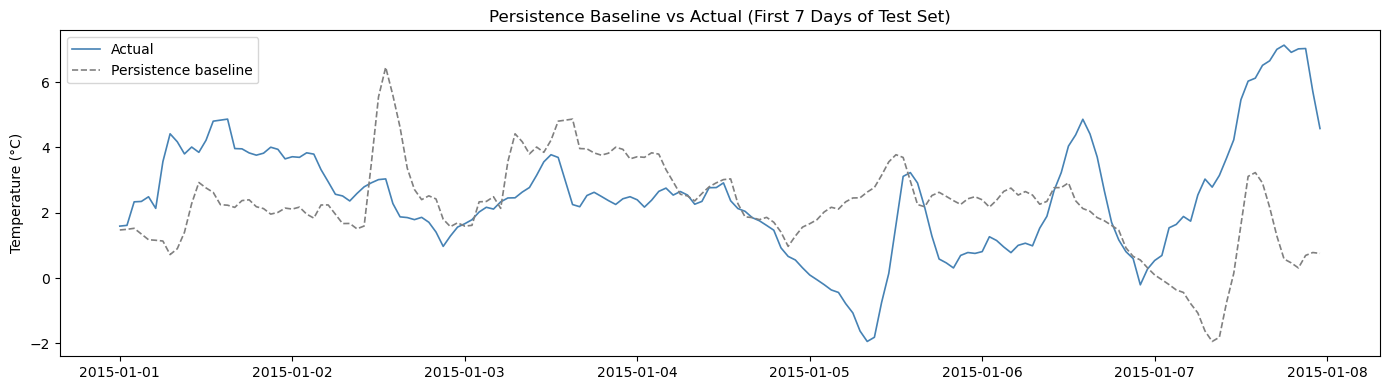

In [8]:
# SECTION 7 – PERSISTENCE BASELINE FORECAST
# T(t+24) = T(t): the simplest possible forecast.
# Every ML model must beat this to justify its complexity.

persistence_preds = test['T_lag_24h'].values

p_rmse = np.sqrt(mean_squared_error(y_test, persistence_preds))
p_mae  = mean_absolute_error(y_test, persistence_preds)
p_r2   = r2_score(y_test, persistence_preds)

print("\n── Persistence Baseline ──")
print(f"  RMSE : {p_rmse:.3f} °C")
print(f"  MAE  : {p_mae:.3f} °C")
print(f"  R²   : {p_r2:.4f}")

n_base = 24 * 7
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index[:n_base], y_test.values[:n_base],
        label='Actual', lw=1.2, color='steelblue')
ax.plot(y_test.index[:n_base], persistence_preds[:n_base],
        label='Persistence baseline', lw=1.2, color='gray', ls='--')
ax.set_title('Persistence Baseline vs Actual (First 7 Days of Test Set)')
ax.set_ylabel('Temperature (°C)'); ax.legend()
plt.tight_layout(); plt.show()


Running TimeSeriesSplit cross-validation (5 folds) ...
  Fold 1: RMSE=3.479  MAE=2.718  train=8,736  val=8,736
  Fold 2: RMSE=3.225  MAE=2.527  train=17,472  val=8,736
  Fold 3: RMSE=3.347  MAE=2.625  train=26,208  val=8,736
  Fold 4: RMSE=2.833  MAE=2.209  train=34,944  val=8,736
  Fold 5: RMSE=2.848  MAE=2.210  train=43,680  val=8,736

  CV RMSE : 3.146 ± 0.263 °C
  CV MAE  : 2.458 ± 0.212 °C


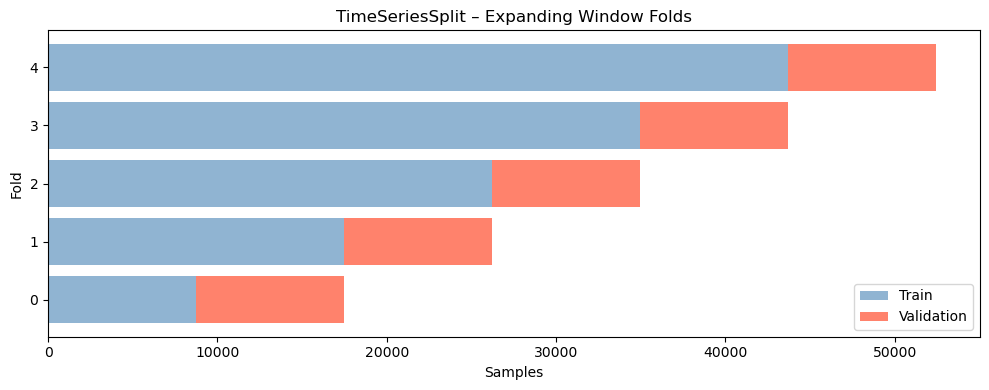

In [9]:
# SECTION 8 – TIME SERIES CROSS-VALIDATION
# TimeSeriesSplit uses an expanding window: each fold trains on
# all data before the validation period. This respects temporal
# order and prevents future data leaking into the training fold.

print("\nRunning TimeSeriesSplit cross-validation (5 folds) ...")
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_model = XGBRegressor(n_estimators=300, learning_rate=0.05,
                             max_depth=5, random_state=42, verbosity=0)
cv_rmse, cv_mae = [], []

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
    xgb_cv_model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    preds = xgb_cv_model.predict(X_train.iloc[vl_idx])
    cv_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[vl_idx], preds)))
    cv_mae.append(mean_absolute_error(y_train.iloc[vl_idx], preds))
    print(f"  Fold {fold+1}: RMSE={cv_rmse[-1]:.3f}  MAE={cv_mae[-1]:.3f}"
          f"  train={len(tr_idx):,}  val={len(vl_idx):,}")

print(f"\n  CV RMSE : {np.mean(cv_rmse):.3f} ± {np.std(cv_rmse):.3f} °C")
print(f"  CV MAE  : {np.mean(cv_mae):.3f} ± {np.std(cv_mae):.3f} °C")

fig, ax = plt.subplots(figsize=(10, 4))
for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
    ax.barh(fold, len(tr_idx), color='steelblue', alpha=0.6,
            label='Train' if fold == 0 else '')
    ax.barh(fold, len(vl_idx), left=len(tr_idx), color='tomato', alpha=0.8,
            label='Validation' if fold == 0 else '')
ax.set_xlabel('Samples'); ax.set_ylabel('Fold')
ax.set_title('TimeSeriesSplit – Expanding Window Folds')
ax.legend(); plt.tight_layout(); plt.show()


Starting Optuna search (50 trials) ...


  0%|          | 0/50 [00:00<?, ?it/s]


Best CV RMSE from Optuna: 3.031 °C
Best hyperparameters:
  n_estimators: 267
  learning_rate: 0.037935787087836265
  max_depth: 3
  subsample: 0.9673304702752854
  colsample_bytree: 0.7036628768237138
  min_child_weight: 21
  reg_alpha: 5.5916772644515875
  reg_lambda: 0.0018722033988054527


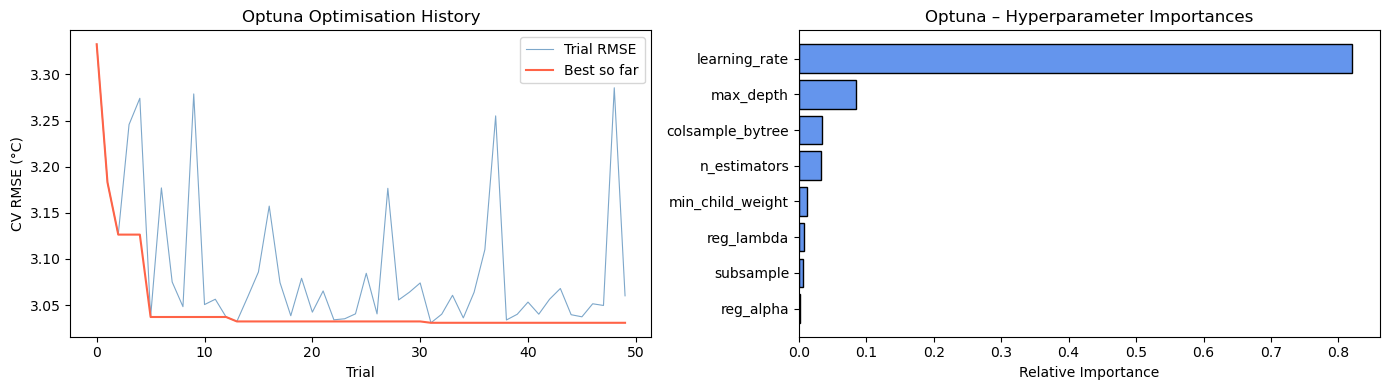

In [10]:
# SECTION 9 – HYPERPARAMETER OPTIMISATION WITH OPTUNA
# Bayesian (TPE) search over XGBoost params using TimeSeriesSplit
# on training data only — test set never touched during tuning.

print("\nStarting Optuna search (50 trials) ...")

def optuna_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 30),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state": 42, "verbosity": 0
    }
    model = XGBRegressor(**params)
    inner_cv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr, vl in inner_cv.split(X_train):
        model.fit(X_train.iloc[tr], y_train.iloc[tr])
        scores.append(np.sqrt(mean_squared_error(
            y_train.iloc[vl], model.predict(X_train.iloc[vl])
        )))
    return np.mean(scores)

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=50, show_progress_bar=True)

best_params = {**study.best_params, "random_state": 42, "verbosity": 0}
print(f"\nBest CV RMSE from Optuna: {study.best_value:.3f} °C")
print("Best hyperparameters:")
for k, v in best_params.items():
    if k not in ("random_state", "verbosity"):
        print(f"  {k}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['value'], color='steelblue', lw=0.8, alpha=0.7,
             label='Trial RMSE')
axes[0].plot(trials_df['value'].cummin(), color='tomato', lw=1.5,
             label='Best so far')
axes[0].set_title('Optuna Optimisation History')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('CV RMSE (°C)'); axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1],
             list(importances.values())[::-1],
             color='cornflowerblue', edgecolor='k')
axes[1].set_title('Optuna – Hyperparameter Importances')
axes[1].set_xlabel('Relative Importance')
plt.tight_layout(); plt.show()

In [11]:
# SECTION 10 – TRAIN ALL MODELS
# Four models + persistence baseline for a complete comparison.
# Ridge is included as a linear baseline; its expected weakness
# due to Non-linearity and Multicollinearity

print("\nTraining all models on full training set ...")

models = {
    "Ridge Regression": {
        "model": Ridge(alpha=10.0),
        "scaled": True
    },
    "Random Forest": {
        "model": RandomForestRegressor(
            n_estimators=300, max_depth=10,
            min_samples_leaf=10, n_jobs=-1, random_state=42
        ),
        "scaled": False
    },
    "LightGBM": {                                         
        "model": LGBMRegressor(
            n_estimators=600, learning_rate=0.03,
            max_depth=6, num_leaves=50,
            subsample=0.75, colsample_bytree=0.75,
            min_child_samples=20,
            random_state=42, verbose=-1
        ),
        "scaled": False
    },
    "XGBoost (tuned)": {
        "model": XGBRegressor(**best_params),
        "scaled": False
    }
}

results = {
    "Persistence Baseline": {
        "RMSE": p_rmse, "MAE": p_mae, "R2": p_r2,
        "preds": persistence_preds
    }
}

for name, cfg in models.items():
    print(f"\nTraining {name} ...")
    Xtr = X_train_sc if cfg["scaled"] else X_train.values
    Xte = X_test_sc  if cfg["scaled"] else X_test.values
    cfg["model"].fit(Xtr, y_train)
    preds = cfg["model"].predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "preds": preds}
    print(f"  RMSE : {rmse:.3f} °C  |  MAE : {mae:.3f} °C  |  R² : {r2:.4f}")



Training all models on full training set ...

Training Ridge Regression ...
  RMSE : 5.296 °C  |  MAE : 2.470 °C  |  R² : 0.5613

Training Random Forest ...
  RMSE : 3.000 °C  |  MAE : 2.356 °C  |  R² : 0.8592

Training LightGBM ...
  RMSE : 2.926 °C  |  MAE : 2.305 °C  |  R² : 0.8661

Training XGBoost (tuned) ...
  RMSE : 2.959 °C  |  MAE : 2.323 °C  |  R² : 0.8630



── Full Model Comparison ──
                        RMSE     MAE      R2
Persistence Baseline  4.3823  3.4381  0.6996
Ridge Regression      5.2956  2.4697  0.5613
Random Forest         3.0001  2.3560  0.8592
LightGBM              2.9256  2.3047  0.8661
XGBoost (tuned)       2.9591  2.3233  0.8630


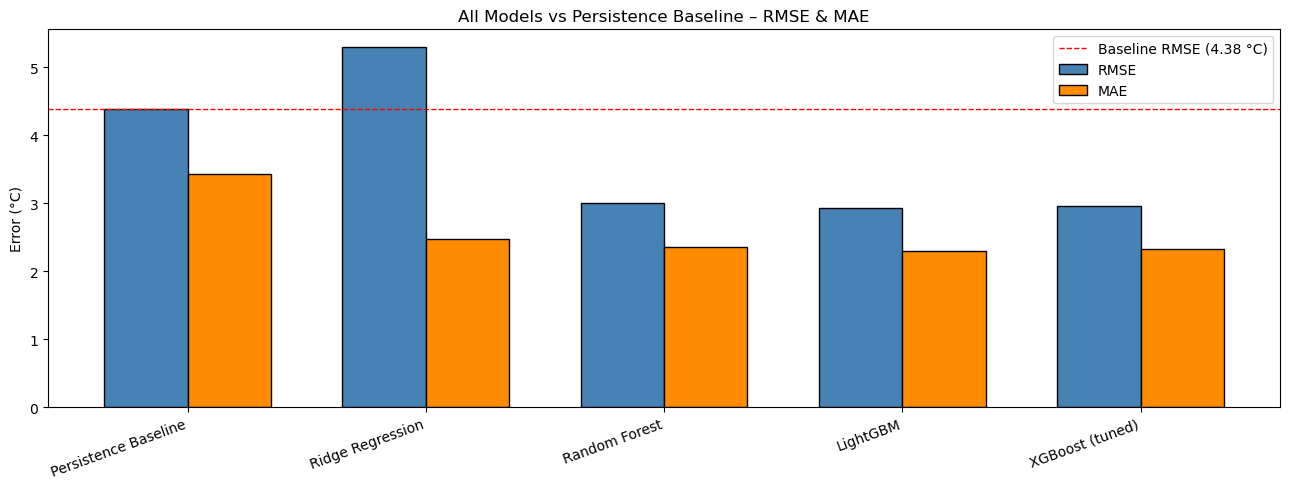

In [12]:
# SECTION 11 – MODEL COMPARISON

metrics_df = pd.DataFrame(
    {k: {m: v for m, v in v.items() if m != "preds"} for k, v in results.items()}
).T.round(4)

print("\n── Full Model Comparison ──")
print(metrics_df.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metrics_df))
w = 0.35
ax.bar(x - w/2, metrics_df['RMSE'], w, label='RMSE',
       color='steelblue', edgecolor='k')
ax.bar(x + w/2, metrics_df['MAE'],  w, label='MAE',
       color='darkorange', edgecolor='k')
ax.axhline(p_rmse, color='red', ls='--', lw=1,
           label=f'Baseline RMSE ({p_rmse:.2f} °C)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, rotation=20, ha='right')
ax.set_ylabel('Error (°C)')
ax.set_title('All Models vs Persistence Baseline – RMSE & MAE')
ax.legend(); plt.tight_layout(); plt.show()


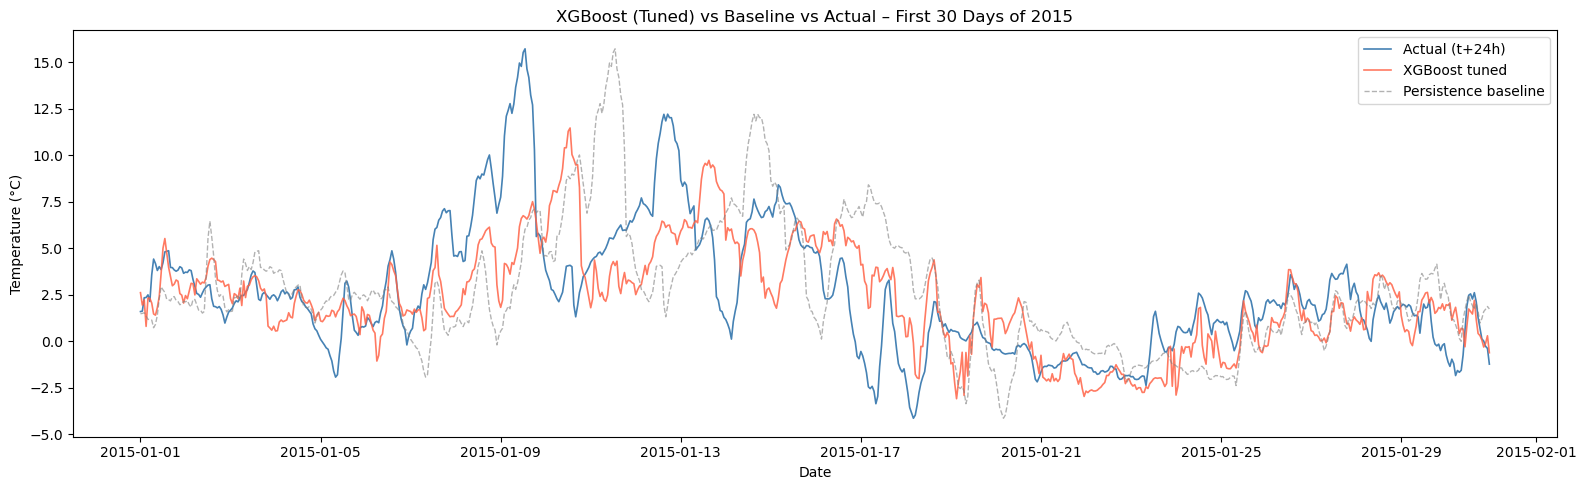

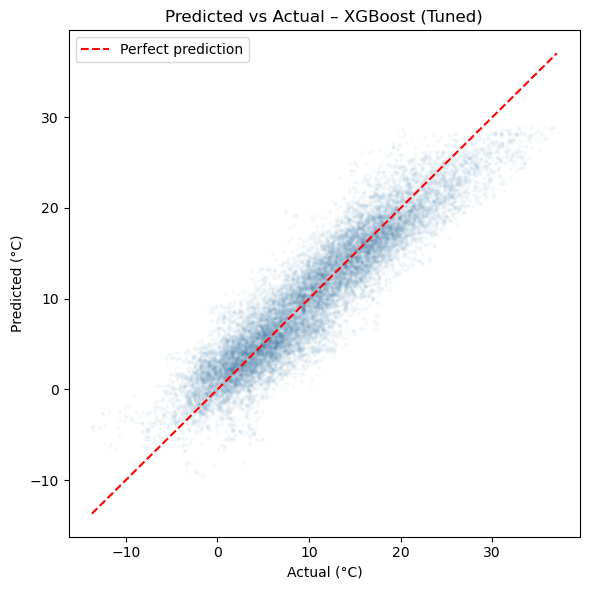

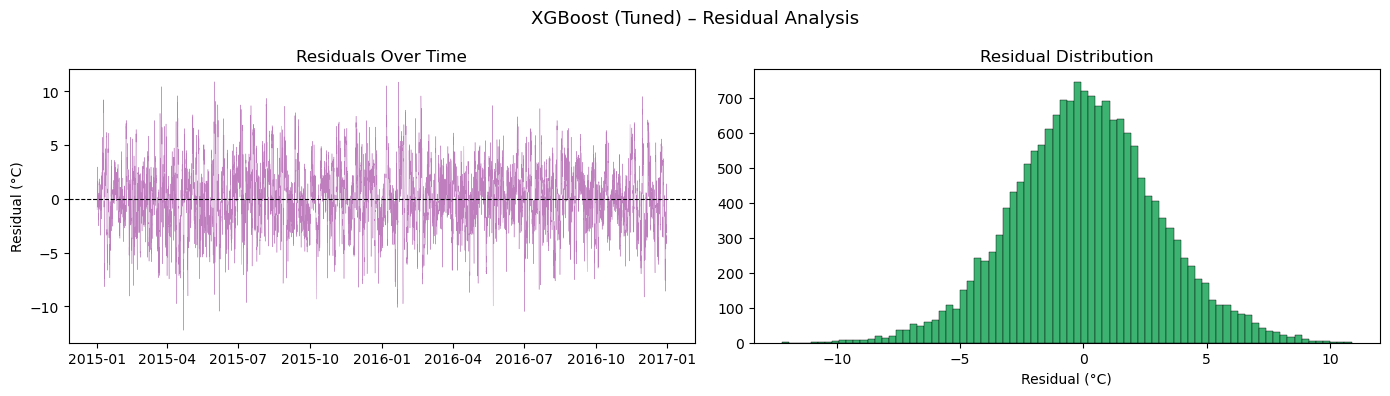


── Numerical Residual Diagnostics ──

Shapiro-Wilk normality test (n=5,000 sample):
  Statistic : 0.9983
  p-value   : 3.1622e-05
  → Residuals are NOT normally distributed (p < 0.05).
    This is common for large weather datasets — the model
    may struggle with extreme temperature events.

Ljung-Box autocorrelation test on residuals:
         lb_stat  lb_pvalue
12  89727.955475        0.0
24  97997.743566        0.0
48  98184.132013        0.0

  → Significant autocorrelation detected in residuals.
    Some temporal patterns remain unexplained by the model.
    A sequential model (e.g. LSTM) might capture these further.


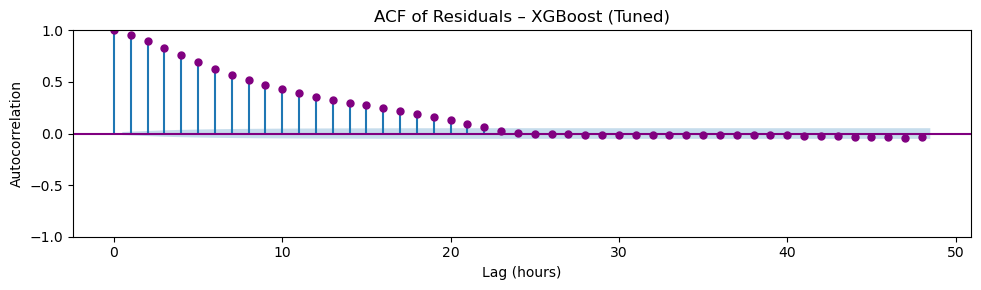

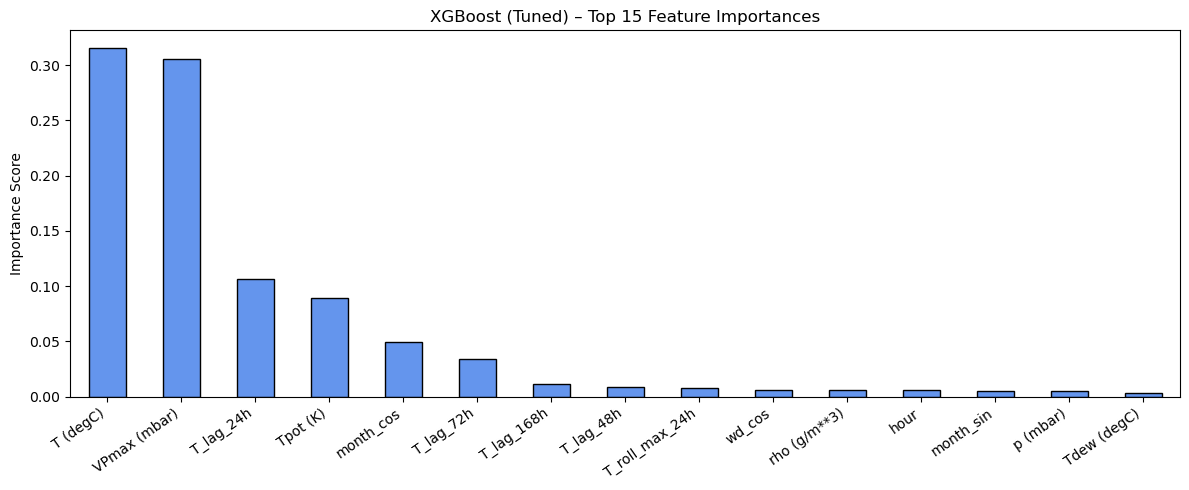

In [13]:

# SECTION 12 – FORECAST vs ACTUAL & RESIDUAL ANALYSIS

best_name  = "XGBoost (tuned)"
best_preds = results[best_name]["preds"]
residuals  = y_test.values - best_preds

# 30-day forecast plot
n_plot = 24 * 30
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index[:n_plot], y_test.values[:n_plot],
        label='Actual (t+24h)', lw=1.2, color='steelblue')
ax.plot(y_test.index[:n_plot], best_preds[:n_plot],
        label='XGBoost tuned', lw=1.2, color='tomato', alpha=0.85)
ax.plot(y_test.index[:n_plot], persistence_preds[:n_plot],
        label='Persistence baseline', lw=1, color='gray', ls='--', alpha=0.6)
ax.set_title('XGBoost (Tuned) vs Baseline vs Actual – First 30 Days of 2015')
ax.set_ylabel('Temperature (°C)'); ax.set_xlabel('Date')
ax.legend(); plt.tight_layout(); plt.show()

# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.values, best_preds, alpha=0.03, s=4, color='steelblue')
lims = [float(y_test.min()), float(y_test.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual (°C)'); ax.set_ylabel('Predicted (°C)')
ax.set_title('Predicted vs Actual – XGBoost (Tuned)')
ax.legend(); plt.tight_layout(); plt.show()

# Visual residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_test.index, residuals, lw=0.3, color='purple', alpha=0.5)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_title('Residuals Over Time'); axes[0].set_ylabel('Residual (°C)')
axes[1].hist(residuals, bins=80, color='mediumseagreen', edgecolor='k', lw=0.3)
axes[1].set_title('Residual Distribution'); axes[1].set_xlabel('Residual (°C)')
plt.suptitle('XGBoost (Tuned) – Residual Analysis', fontsize=13)
plt.tight_layout(); plt.show()


print("\n── Numerical Residual Diagnostics ──")

# Shapiro-Wilk normality test
# H₀: residuals are normally distributed.

np.random.seed(42)
sample = np.random.choice(residuals, size=5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"\nShapiro-Wilk normality test (n=5,000 sample):")
print(f"  Statistic : {shapiro_stat:.4f}")
print(f"  p-value   : {shapiro_p:.4e}")
if shapiro_p < 0.05:
    print("  → Residuals are NOT normally distributed (p < 0.05).")
    print("    This is common for large weather datasets — the model")
    print("    may struggle with extreme temperature events.")
else:
    print("  → Residuals appear normally distributed (p ≥ 0.05).")

# Ljung-Box autocorrelation test on residuals
# H₀: residuals show no autocorrelation up to lag k.

lb_result = acorr_ljungbox(residuals, lags=[12, 24, 48], return_df=True)
print(f"\nLjung-Box autocorrelation test on residuals:")
print(lb_result.to_string())
if (lb_result['lb_pvalue'] < 0.05).any():
    print("\n  → Significant autocorrelation detected in residuals.")
    print("    Some temporal patterns remain unexplained by the model.")
    print("    A sequential model (e.g. LSTM) might capture these further.")
else:
    print("\n  → No significant autocorrelation in residuals (p ≥ 0.05).")
    print("    The model has successfully captured the temporal structure.")

# ACF plot of residuals — visual complement to the Ljung-Box test
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(residuals, lags=48, ax=ax, color='purple', alpha=0.05)
ax.set_title('ACF of Residuals – XGBoost (Tuned)')
ax.set_xlabel('Lag (hours)'); ax.set_ylabel('Autocorrelation')
plt.tight_layout(); plt.show()

# Feature importance
importance = pd.Series(
    models["XGBoost (tuned)"]["model"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importance.head(15).plot(
    kind='bar', figsize=(12, 5), color='cornflowerblue', edgecolor='k'
)
plt.title('XGBoost (Tuned) – Top 15 Feature Importances')
plt.ylabel('Importance Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()


In [14]:

# SECTION 13 – FINAL SUMMARY

print("\n" + "="*62)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("  Forecast horizon : 24 hours ahead")
print("  Train            : 2009–2014  |  Test : 2015–2016")
print("="*62)
for name, vals in results.items():
    marker = " ◄ best ML model" if name == best_name else ""
    print(f"\n  {name}{marker}")
    print(f"    RMSE : {vals['RMSE']:.3f} °C")
    print(f"    MAE  : {vals['MAE']:.3f} °C")
    print(f"    R²   : {vals['R2']:.4f}")

print("\n── Improvement over persistence baseline ──")
for name, vals in results.items():
    if name == "Persistence Baseline":
        continue
    gain = ((p_rmse - vals['RMSE']) / p_rmse) * 100
    direction = "better" if gain > 0 else "WORSE"
    print(f"  {name}: RMSE {abs(gain):.1f}% {direction} than baseline")

print("""
Methodology:
  - ACF/PACF + decomposition : confirmed daily & annual seasonality
  - TimeSeriesSplit (5 folds): robust CV without future leakage
  - Optuna (50 trials)       : Bayesian hyperparameter search
  - Persistence baseline     : naive benchmark all models must beat
  - Shapiro-Wilk + Ljung-Box : formal residual diagnostics
  - Leakage prevention       : all lags >= 24h, chronological split

Note on Ridge: expected to perform poorly due to non-linearity
and multicollinearity in the feature set. Included as a linear
baseline only — its weakness confirms the need for tree-based models.

""")


  FINAL MODEL PERFORMANCE SUMMARY
  Forecast horizon : 24 hours ahead
  Train            : 2009–2014  |  Test : 2015–2016

  Persistence Baseline
    RMSE : 4.382 °C
    MAE  : 3.438 °C
    R²   : 0.6996

  Ridge Regression
    RMSE : 5.296 °C
    MAE  : 2.470 °C
    R²   : 0.5613

  Random Forest
    RMSE : 3.000 °C
    MAE  : 2.356 °C
    R²   : 0.8592

  LightGBM
    RMSE : 2.926 °C
    MAE  : 2.305 °C
    R²   : 0.8661

  XGBoost (tuned) ◄ best ML model
    RMSE : 2.959 °C
    MAE  : 2.323 °C
    R²   : 0.8630

── Improvement over persistence baseline ──
  Ridge Regression: RMSE 20.8% WORSE than baseline
  Random Forest: RMSE 31.5% better than baseline
  LightGBM: RMSE 33.2% better than baseline
  XGBoost (tuned): RMSE 32.5% better than baseline

Methodology:
  - ACF/PACF + decomposition : confirmed daily & annual seasonality
  - TimeSeriesSplit (5 folds): robust CV without future leakage
  - Optuna (50 trials)       : Bayesian hyperparameter search
  - Persistence baseline     : 